# Simple example illustrating basic aspects of ridge linear regression

In [1]:
import numpy as np
import pandas as pd

pd.set_option('display.precision', 4)

## 1. Load `murders.txt` data from class

In [2]:
df = pd.read_csv('murders.txt', sep=' ')
df['x_0'] = 1
print(df)

    inhabitants  poverty  unemployment  murders  x_0
0           587     16.5           6.2     11.2    1
1           643     20.5           6.4     13.4    1
2           635     26.3           9.3     40.7    1
3           692     16.5           5.3      5.3    1
4          1248     19.2           7.3     24.8    1
5           643     16.5           5.9     12.7    1
6          1964     20.2           6.4     20.9    1
7          1531     21.3           7.6     35.7    1
8           713     17.2           4.9      8.7    1
9           749     14.3           6.4      9.6    1
10         7895     18.1           6.0     14.5    1
11          762     23.1           7.4     26.9    1
12         2793     19.1           5.8     15.7    1
13          741     24.7           8.6     36.2    1
14          625     18.6           6.5     18.1    1
15          854     24.9           8.3     28.9    1
16          716     17.9           6.7     14.9    1
17          921     22.4           8.6     25.

In [3]:
# put data into X matrix and y column

X = df[['x_0', 'inhabitants', 'poverty', 'unemployment']].to_numpy()
y = df[['murders']].to_numpy()

print(X.shape, y.shape)

(20, 4) (20, 1)


## 2. Train/test split for later validation

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(13, 4) (13, 1)
(7, 4) (7, 1)


## 3. Preprocessing: first normalize training set, then apply same transformation to test

In [5]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler().fit(X_train)   # computes means and stdevs for each column in X_train
X_train_scaled = scaler.transform(X_train)             # substracts mean and divides by stdev (estimated from training)
X_test_scaled = scaler.transform(X_test)               # substracts mean and divides by stdev (estimated from training)

X_train_scaled[:,0] = 1   # undo transformation for all-1 column
X_test_scaled[:,0] = 1   # undo transformation for all-1 column

print(X_train_scaled.mean(axis=0))
print(X_test_scaled.mean(axis=0))

[ 1.00000000e+00  6.83214169e-17 -5.44436291e-16  1.70803542e-16]
[ 1.          2.26114699 -0.15256269 -0.21991089]


__Question__: why are means for X_test_scaled not zero? and for X_train_scaled?

### Why are the means different?

The `StandardScaler` is **fitted only on `X_train`**:

$$
x_{scaled} = \frac{x - \mu_{train}}{\sigma_{train}}
$$

- **`X_train_scaled`** has mean ≈ 0 because we subtract the training mean and divide by the training standard deviation.
- **`X_test_scaled`** does **not** have mean 0 because it is transformed using the **training statistics**, not its own distribution.  


## 4. Train ridge regression model for several $\lambda$ values

As explained in class, for each value of $\lambda$ that we want to try,
we use _maximum a posteriori_ method to find linear coefficients $\theta_0, \theta_1, ..$:

$$\theta_{ridge} = (X^T X + \lambda I)^{-1} X^T y$$

### train model, using formulas from slides

1. For each $\lambda\in\Lambda$:
    - compute optimal solution $\hat{\mathbf{\theta}}_{\lambda} = (\mathbf{X}^T\mathbf{X} + \lambda I)^{-1}\mathbf{X}^T\mathbf{y}$
    - compute "hat" matrix $H_{\lambda} = \mathbf{X}(\mathbf{X}^T\mathbf{X} + \lambda I)^{-1}\mathbf{X}^T$
    - compute loocv directly for each $\lambda$ (no need to use folds etc.):

$$
loocv(\lambda) = \frac{1}{n} \sum_{i=1}^n \left( \frac{y_i - \mathbf{x}_i \mathbf{\theta}_{\lambda}}{1 - h_{ii}}  \right)^2
$$
    
2. Return $\lambda$ with minimum *loocv*


In [6]:
from sklearn.metrics import mean_squared_error

lambdas = np.logspace(start = -4, stop = 1.2, num = 50, base = 10.0)
print(lambdas)
results = []
X = X_train_scaled.copy()
y = y_train.copy()
n = y.shape[0]
d = X.shape[1]

for l in lambdas:
    XtX = X.T @ X
    XtX_inv = np.linalg.inv( XtX + l * np.identity(n=d))
    coefs = (XtX_inv) @ X.T @ y
    l2_norm = np.linalg.norm(coefs[1:], ord=2)
    hatmat = X @ XtX_inv @ X.T
    trace_hatmat = np.trace(hatmat)
    y_pred = X @ coefs
    loocv = 1/n * np.sum([((y[i] - y_pred[i]) / (1 - hatmat[i,i]))**2 for i in range(n)])
    mse = mean_squared_error(y, y_pred)
    gcv = mse / (1 - trace_hatmat/n)**2
    results.append([l, mse, loocv, gcv, l2_norm])

df = pd.DataFrame(results, columns = ['lambda', 'training_mse', 'loocv', 'gcv', 'l2'])
df.sort_values(by='lambda')


[1.00000000e-04 1.27679875e-04 1.63021505e-04 2.08145654e-04
 2.65760111e-04 3.39322177e-04 4.33246132e-04 5.53168120e-04
 7.06284364e-04 9.01782994e-04 1.15139540e-03 1.47010021e-03
 1.87702211e-03 2.39657948e-03 3.05994969e-03 3.90693994e-03
 4.98837603e-03 6.36915228e-03 8.13212567e-03 1.03830879e-02
 1.32571137e-02 1.69266662e-02 2.16119462e-02 2.75941059e-02
 3.52321199e-02 4.49843267e-02 5.74359321e-02 7.33341263e-02
 9.36329209e-02 1.19550396e-01 1.52641797e-01 1.94892855e-01
 2.48838954e-01 3.17717266e-01 4.05661008e-01 5.17947468e-01
 6.61314680e-01 8.44365757e-01 1.07808514e+00 1.37649776e+00
 1.75751062e+00 2.24398737e+00 2.86512027e+00 3.65818198e+00
 4.67076218e+00 5.96362332e+00 7.61434680e+00 9.72198848e+00
 1.24130227e+01 1.58489319e+01]


,lambda,training_mse,loocv,gcv,l2
0,0.0001,8.5261,38.3226,17.7886,8.9876
1,0.0001,8.5261,38.3210,17.7885,8.9875
2,0.0002,8.5261,38.3189,17.7883,8.9875
3,0.0002,8.5261,38.3163,17.7881,8.9874
4,0.0003,8.5261,38.3129,17.7879,8.9872
5,0.0003,8.5261,38.3086,17.7876,8.9871
6,0.0004,8.5261,38.3031,17.7872,8.9868
7,0.0006,8.5261,38.2961,17.7867,8.9865
8,0.0007,8.5261,38.2871,17.7860,8.9862
9,0.0009,8.5261,38.2756,17.7852,8.9857


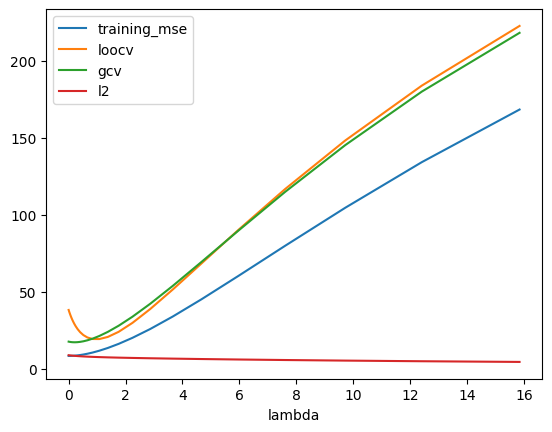

In [7]:
df.plot(kind='line', x='lambda');

### select best lambda according to loocv; re-train on the whole training set to obtain model using best lambda

In [ ]:
best_lambda = df.loc[df['loocv'].idxmin()]['lambda']

print(f'best lambda value: {best_lambda:.4f}')

# apply formula with "best lambda"
theta_vector = np.linalg.inv( X_train_scaled.T @ X_train_scaled + best_lambda * np.identity(n=d)) @ X_train_scaled.T @ y


best lambda value: 1.0781


### as a sanity check, see what RidgeRegressionCV from scikit-learn obtains as best lambda

In [8]:
from sklearn.linear_model import RidgeCV

print(f'there are {X_train_scaled.shape[0]} training examples.')
results = []
for k in range(2, 6+1):
    ridge = RidgeCV(alphas=lambdas, fit_intercept=False, cv=k)   #k-fold cross-val
    clf = ridge.fit(X_train_scaled, y_train)
    results.append([k, clf.alpha_])

## "efficient"  way:
ridge = RidgeCV(alphas=lambdas, fit_intercept=False, cv=None)
clf = ridge.fit(X_train_scaled, y_train)
results.append(['efficient', clf.alpha_])

pd.DataFrame(results, columns=['cross-val method (k)', 'best lambda'])

there are 13 training examples.


,cross-val method (k),best lambda
0,2,0.8444
1,3,1.0781
2,4,1.0781
3,5,0.8444
4,6,0.6613
5,efficient,1.0781


## 4. Test trained linear model to predict `murders` on __unseen data__  (test partition)

In [ ]:
# make predictions on unseen test points (from test partition)
y_pred = X_test_scaled @ theta_vector

# compute squared error for each example
abs_error = np.abs(y_pred - y_test)
sq_error = np.square(y_pred - y_test)

# show them in table
dict_data = {'target': y_test.ravel(), 'pred': y_pred.ravel(), 'abs_error': abs_error.ravel(), 'squared_error': sq_error.ravel()}
df = pd.DataFrame.from_dict(dict_data)
print(df)

print(f'\nThe TEST mean squared error is: {mean_squared_error(y_pred, y_test)}')

   target     pred  abs_error  squared_error
0    21.7  27.2510     5.5510        30.8142
1    13.4  16.0910     2.6910         7.2417
2    25.7  21.1204     4.5796        20.9727
3     8.7   4.2180     4.4820        20.0887
4    14.5  29.9480    15.4480       238.6395
5    25.8  31.4877     5.6877        32.3502
6    20.9  19.1771     1.7229         2.9684

The TEST mean squared error is: 50.43935197299237


(np.float64(2.854470981303635),
 np.float64(32.85121546989685),
 np.float64(2.854470981303635),
 np.float64(32.85121546989685))

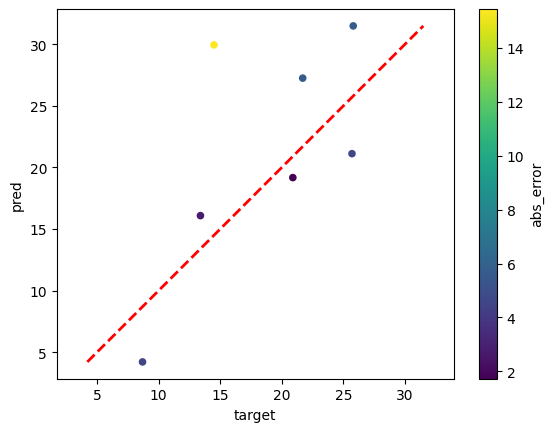

In [ ]:
ax = df.plot.scatter(x='target', y='pred', c='abs_error')

# diagonal (y = x)
lims = [
    min(df['target'].min(), df['pred'].min()),
    max(df['target'].max(), df['pred'].max())
]
ax.plot(lims, lims, 'r--', linewidth=2)

ax.axis('equal')